# K-Means Clustering on Iris Dataset

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y_true = iris.target
print("Dataset shape:", X.shape)

Dataset shape: (150, 4)


In [3]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)
y_pred = kmeans.labels_

In [4]:
# Evaluation - Silhouette Score
silhouette = silhouette_score(X, y_pred)
print("Silhouette Score:", round(silhouette, 4))

Silhouette Score: 0.5528


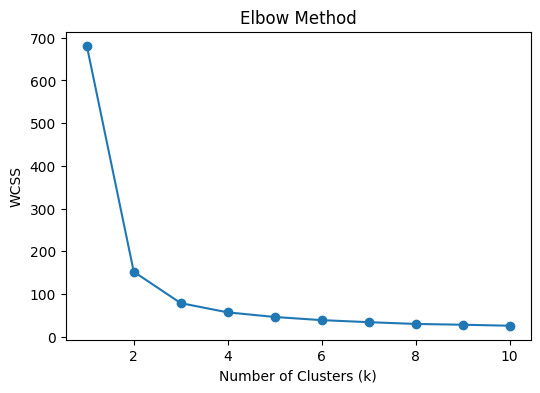

In [5]:
# WCSS (Within-Cluster Sum of Squares) and Elbow Method
wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    wcss.append(km.inertia_)

# Elbow Plot
plt.figure(figsize=(6, 4))
plt.plot(k_range, wcss, 'o-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

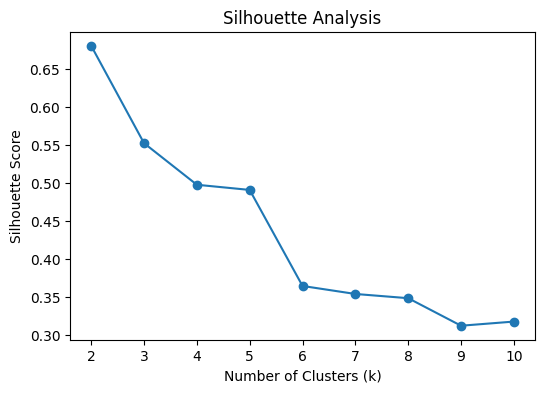

In [6]:
# Silhouette Score for different k values
silhouette_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

plt.figure(figsize=(6, 4))
plt.plot(k_range_sil, silhouette_scores, 'o-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

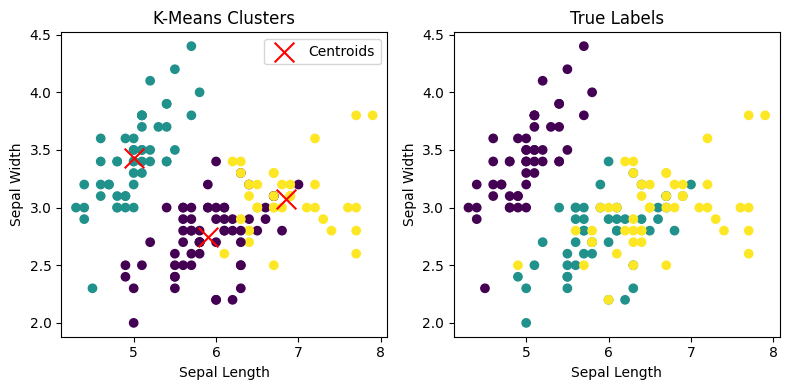

In [7]:
# Plot clusters (using first 2 features)
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='red', marker='x', s=200, label='Centroids')
plt.title('K-Means Clusters')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis')
plt.title('True Labels')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.tight_layout()
plt.show()

In [9]:
# Print WCSS for k=3
print("WCSS for k=3:", round(kmeans.inertia_, 4))

WCSS for k=3: 78.8514
